# Poisson-GLM

This notebook implements Generalized Linear Model (GLM) analysis inspired by the neuroGLM toolkit (https://github.com/memming/neuroGLM) and the methodology from:

**Park et al. (2014). "Encoding and decoding in parietal cortex during sensorimotor decision-making." Nature Neuroscience 17, 1395-1403.**



In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
from scipy.io import loadmat
from scipy import stats, signal
from scipy.sparse import csr_matrix, vstack, hstack, issparse
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.ndimage import gaussian_filter1d
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


In [4]:
from imports import *
from src.utils import poisson_glm_utils
from config import dir_config

from config.poisson_glm_config import StateBasedPoissonGLMConfig

In [5]:
compiled_dir = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)

session_to_exclude = ["210210_GP_JP", "241209_GP_TZ"]

session_metadata = pd.read_csv(Path(processed_dir, 'sessions_metadata.csv'))
session_metadata = session_metadata[~np.isin(session_metadata["session_id"], session_to_exclude)]

neuron_metadata = pd.read_csv(Path(processed_dir, 'neuron_metadata.csv'))
neuron_metadata = neuron_metadata[~np.isin(neuron_metadata["session_id"], session_to_exclude)]

with open(Path(processed_dir, f'glm_hmm_masked_final.pkl'), 'rb') as f:
    glm_hmm = pickle.load(f)

poisson_glm_config = StateBasedPoissonGLMConfig()

In [6]:
# Feature indices for easy access
feature_idx = {
    'target_start': 0,
    'target_end': poisson_glm_config.FEATURES_TARGET,
    'stim_start': poisson_glm_config.FEATURES_TARGET,
    'stim_end': poisson_glm_config.FEATURES_TARGET + poisson_glm_config.FEATURES_STIMULUS,
    'stim_offset_start': poisson_glm_config.FEATURES_TARGET + poisson_glm_config.FEATURES_STIMULUS,
    'stim_offset_end': poisson_glm_config.FEATURES_TARGET + poisson_glm_config.FEATURES_STIMULUS + poisson_glm_config.FEATURE_STIMULUS_OFFSET,
    'saccade_start': poisson_glm_config.FEATURES_TARGET + poisson_glm_config.FEATURES_STIMULUS + poisson_glm_config.FEATURE_STIMULUS_OFFSET,
    'saccade_end': poisson_glm_config.FEATURES_TARGET + poisson_glm_config.FEATURES_STIMULUS + poisson_glm_config.FEATURE_STIMULUS_OFFSET + poisson_glm_config.FEATURES_SACCADE,
    'history_start': poisson_glm_config.FEATURES_TARGET + poisson_glm_config.FEATURES_STIMULUS + poisson_glm_config.FEATURE_STIMULUS_OFFSET + poisson_glm_config.FEATURES_SACCADE,
    'history_end': poisson_glm_config.FEATURES_TARGET + poisson_glm_config.FEATURES_STIMULUS + poisson_glm_config.FEATURE_STIMULUS_OFFSET + poisson_glm_config.FEATURES_SACCADE + poisson_glm_config.FEATURES_HISTORY,
    'intercept_idx': poisson_glm_config.get_total_features() - 1
}

print(f"Total features: {poisson_glm_config.get_total_features()}")

Total features: 705


### Helper Functions

In [7]:
def extract_neuron_data(neuron_id):
    session_name = neuron_metadata.loc[neuron_metadata["neuron_id"] == neuron_id, "session_id"].values[0]
    data_path = Path(compiled_dir, session_name)

    print(f"Analyzing neuron {neuron_id} from session {session_name}")

    # Load neural and behavioral data
    try:
        spike_times = np.load(data_path / "spike_times.npy")
        spike_clusters = np.load(data_path / "spike_clusters.npy")
    except:
        spike_times = loadmat(Path(compiled_dir, session_name, "spike_times.mat"))
        spike_times = spike_times["spike_times"][0]
        spike_clusters = loadmat(Path(compiled_dir, session_name, "spike_clusters.mat"))
        spike_clusters = spike_clusters["spike_clusters"][0]

    # Get neuron spike times
    cluster_id = neuron_metadata.cluster[neuron_metadata["neuron_id"] == neuron_id].values[0]
    neuron_spike_times = spike_times[spike_clusters == cluster_id]
    neuron_spike_times = (neuron_spike_times / 30).round().astype(int)  # Convert to ms

    # Get timestamps and trial data
    timestamps = pd.read_csv(Path(compiled_dir, session_name, f"{session_name}_timestamps.csv"), index_col=None)
    trial_info = pd.read_csv(Path(compiled_dir, session_name, f"{session_name}_trial.csv"), index_col=None)

    # Process trial data
    GP_trial_data = trial_info[trial_info.task_type == 1].reset_index(drop=True)
    # signed coherence
    GP_trial_data["signed_coherence"] = GP_trial_data["coherence"] * (2*GP_trial_data["target"]-1)

    # Get GLM-HMM states
    confidence_threshold = 0.8
    model = glm_hmm["model"]["models"][session_name]
    choices = glm_hmm["data"][session_name]["choices"].values.reshape(-1, 1)
    input_data = np.array(glm_hmm["data"][session_name][["normalized_stimulus", "bias", "prev_choice_1", "prev_target_1"]])

    if glm_hmm["data"][session_name]["mask"] is None:
        mask = None
    else:
        mask = glm_hmm["data"][session_name]["mask"]
    mask = np.ones_like(choices, dtype=bool) if mask is None else mask

    posterior_probs = model.expected_states(data=choices, input=input_data, mask=np.array(mask).reshape(-1, 1))[0]
    biased_idx = (posterior_probs[:, 0] > confidence_threshold) & np.array(mask)
    unbiased_idx = (posterior_probs[:, 1] > confidence_threshold) & np.array(mask)

    GP_trial_data["state"] = np.nan
    GP_trial_data.loc[np.where(biased_idx)[0], "state"] = 1
    GP_trial_data.loc[np.where(unbiased_idx)[0], "state"] = 0

    GP_trial_data = GP_trial_data[GP_trial_data.state.notna()]
    GP_trial_data = GP_trial_data[GP_trial_data.reaction_time.notna()]

    coh_levels = np.sort(GP_trial_data['signed_coherence'].unique()) /100  # Normalize coherence

    # Keep only correct trials
    GP_trial_data = GP_trial_data[GP_trial_data.outcome == 1].reset_index()

    print(f"Found {len(GP_trial_data)} valid trials")
    print(f"Neuron has {len(neuron_spike_times)} spikes")
    print(f"State distribution: {GP_trial_data.state.value_counts().to_dict()}")

    return GP_trial_data, neuron_spike_times, timestamps, coh_levels

def create_neuroglm_trials(session_data, timestamps, neuron_spike_times, bin_size=1.0):
    """
    Create trial structure following neuroGLM format.
    """
    trials = []

    # Convert timestamps to ms
    timestamps_ms = (timestamps / 30).round()

    for idx, row in session_data.iterrows():
        trial_idx = row.trial_number - 1  # Convert to 0-based

        # Trial timing (relative to target onset - 50ms)
        target_onset = timestamps_ms.loc[trial_idx, "target_onset"]
        trial_start = target_onset - 50
        trial_end = timestamps_ms.loc[trial_idx, "response_onset"]
        duration = trial_end - trial_start

        if pd.isna(duration) or duration <= 0:
            continue

        # Get trial spike times (relative to trial start)
        trial_spikes = neuron_spike_times[
            (neuron_spike_times >= trial_start) &
            (neuron_spike_times <= trial_end)
        ] - trial_start

        # Create binned spike train
        n_bins = int(np.ceil(duration / bin_size))
        spike_train = np.zeros(n_bins)

        for spike_time in trial_spikes:
            bin_idx = int(np.floor(spike_time / bin_size))
            if 0 <= bin_idx < n_bins:
                spike_train[bin_idx] += 1

        # Event timings (relative to trial start)
        events = {
            'target_onset': 50,  # Always 50ms into trial
            'stimulus_onset': timestamps_ms.loc[trial_idx, "stimulus_onset"] - trial_start,
            'stimulus_offset': timestamps_ms.loc[trial_idx, "response_onset"] - trial_start,
            'response_onset': timestamps_ms.loc[trial_idx, "response_onset"] - trial_start,
        }

        # Trial structure
        trial = {
            'duration': duration,
            'spike_train': spike_train,
            'n_bins': n_bins,

            # Event timings
            'target_onset': events['target_onset'],
            'stimulus_onset': events['stimulus_onset'],
            'stimulus_offset': events['stimulus_offset'],
            'response_onset': events['response_onset'],

            # Experimental variables
            'coherence': row.signed_coherence / 100,  # Normalize coherence
            'choice': row.choice,
            'state': row.state,  # Bias state from GLM-HMM
            'reaction_time': row.reaction_time,

            # Trial metadata
            'trial_idx': int(trial_idx),
            # 'original_idx': idx
        }

        trials.append(trial)

    return trials

def build_design_matrix(trials, coh_levels):
    # Initialize containers
    trial_matrices = []
    trial_spike_trains = []

    # Process each trial
    for trial in trials:
        trial_duration = int(trial['duration'])
        trial_design = np.zeros((trial_duration, poisson_glm_config.get_total_features()))

        # 1. TARGET ONSET COMPONENT
        target_bin = int(trial['target_onset'])
        if 0 < target_bin <= trial_duration:
            target_matrix = np.zeros((trial_duration, 1))
            target_matrix[target_bin-1] = 1.0
            target_conv, _ = poisson_glm_utils.convolve_with_basis(
                target_matrix,
                poisson_glm_config.TARGET_BASIS,
                poisson_glm_config.TARGET_DURATION_MS,
                poisson_glm_config.TARGET_SPACING_MS,
                effect= poisson_glm_config.TARGET_EFFECT
            )
            target_start = feature_idx['target_start'] + int(trial['state']) * poisson_glm_config.TARGET_N_BASES
            target_end = target_start + poisson_glm_config.TARGET_N_BASES
            trial_design[:, target_start:target_end] = target_conv

        # 2. STIMULUS COHERENCE COMPONENT
        stim_bin = int(trial['stimulus_onset'])
        resp_bin = int(trial['response_onset'])
        if 0 < stim_bin < resp_bin <= trial_duration:
            stim_matrix = np.zeros((trial_duration, 1))
            stim_matrix[stim_bin-1:resp_bin] = 1.0
            stim_conv, _ = poisson_glm_utils.convolve_with_basis(
                stim_matrix,
                poisson_glm_config.STIMULUS_BASIS,
                poisson_glm_config.STIMULUS_DURATION_MS,
                poisson_glm_config.STIMULUS_SPACING_MS,
                effect= poisson_glm_config.STIMULUS_EFFECT
            )

            # Assign to coherence-specific and state-specific features
            coh_idx = np.where(coh_levels == trial['coherence'])[0][0]
            state_idx = int(trial['state'])
            coh_start = feature_idx['stim_start'] + coh_idx * poisson_glm_config.STIMULUS_N_BASES + state_idx * poisson_glm_config.STIMULUS_N_BASES * len(coh_levels)
            coh_end = coh_start + poisson_glm_config.STIMULUS_N_BASES
            trial_design[:, coh_start:coh_end] = stim_conv

        # 3. STIMULUS OFFSET COHERENCE COMPONENT
        stim_offset_bin = int(trial['stimulus_offset'])
        if 0 < stim_offset_bin <= trial_duration:
            stim_offset_matrix = np.zeros((trial_duration, 1))
            stim_offset_matrix[stim_offset_bin-1] = 1.0
            stim_offset_conv, _ = poisson_glm_utils.convolve_with_basis(
                stim_offset_matrix,
                poisson_glm_config.STIMULUS_OFFSET_BASIS,
                poisson_glm_config.STIMULUS_OFFSET_DURATION_MS,
                poisson_glm_config.STIMULUS_OFFSET_SPACING_MS,
                effect= poisson_glm_config.STIMULUS_OFFSET_EFFECT
            )

            # Assign to coherence-specific and state-specific features
            coh_idx = np.where(coh_levels == trial['coherence'])[0][0]
            state_idx = int(trial['state'])
            coh_start = feature_idx['stim_offset_start'] + coh_idx * poisson_glm_config.STIMULUS_OFFSET_N_BASES + state_idx * poisson_glm_config.STIMULUS_OFFSET_N_BASES * len(coh_levels)
            coh_end = coh_start + poisson_glm_config.STIMULUS_OFFSET_N_BASES
            trial_design[:, coh_start:coh_end] = stim_offset_conv

        # 4. SACCADE/CHOICE COMPONENT
        if 0 < resp_bin <= trial_duration:
            saccade_matrix = np.zeros((trial_duration, 1))
            saccade_matrix[resp_bin-1] = 1.0
            saccade_conv, _ = poisson_glm_utils.convolve_with_basis(
                saccade_matrix,
                poisson_glm_config.SACCADE_BASIS,
                poisson_glm_config.SACCADE_DURATION_MS,
                poisson_glm_config.SACCADE_SPACING_MS,
                effect= poisson_glm_config.SACCADE_EFFECT
            )

            # Assign to choice-specific features
            choice_idx = int(trial['choice'])
            state_idx = int(trial['state'])
            choice_start = feature_idx['saccade_start'] + choice_idx * poisson_glm_config.SACCADE_N_BASES + state_idx * poisson_glm_config.SACCADE_N_BASES * poisson_glm_config.N_CHOICE_OPTIONS
            choice_end = choice_start + poisson_glm_config.SACCADE_N_BASES
            trial_design[:, choice_start:choice_end] = saccade_conv


        # 5. POST-SPIKE HISTORY COMPONENT
        history_matrix = poisson_glm_utils.create_post_spike_history_matrix(trial['spike_train'])
        trial_design[:, feature_idx['history_start']:feature_idx['history_end']] = history_matrix

        # 6. INTERCEPT TERM
        trial_design[:, feature_idx['intercept_idx']] = 1.0

        # Store processed trial
        trial_matrices.append(csr_matrix(trial_design))
        trial_spike_trains.append(trial['spike_train'])

    X = vstack(trial_matrices, format='csr')
    y = np.concatenate(trial_spike_trains)

    return X, y

def fit_poisson_glm(X, y):
    if issparse(X):
        X = X.toarray()  # Convert to dense for faster computation in this case
    # Strategy 2: Feature standardization for better conditioning
    X_means = X.mean(axis=0)
    X_stds = X.std(axis=0)

    # Avoid division by zero
    X_stds[X_stds < 1e-8] = 1.0

    # Standardize all features except intercept
    # In fit_poisson_glm, improve standardization:
    X_scaled = X.copy()
    X_scaled[:, :-1] = (X[:, :-1] - X_means[:-1]) / (X_stds[:-1] + 1e-6)  # Add small epsilon
    # Clip extreme standardized values
    X_scaled = np.clip(X_scaled, -10, 10)

    def loss_fun(w):
        eta = X_scaled @ w
        if np.any(y[eta < -15]>0):
            return 1e20  # Penalty if rate is 0 but spikes are present
        else:
            eta = np.clip(eta, -15, 15)  # Prevent overflow
            mu = np.exp(eta)
            return np.sum(mu) - np.dot(y, eta) + 0.1 * np.dot(w, w)

    def grad_fun(w):
        eta = X_scaled @ w
        eta = np.clip(eta, -15, 15)
        mu = np.exp(eta)
        return X_scaled.T @ (mu - y) + 0.2 * w

    n_features = X_scaled.shape[1]
    w_init = np.zeros(n_features)
    w_init[-1] = np.log(max(y.mean(), 1e-8))  # Smart intercept

    print(f"\nOptimizing {n_features} parameters...")
    start_time = time.time()

    result = minimize(
        fun=loss_fun,
        x0=w_init,
        method='L-BFGS-B',
        jac=grad_fun,
        options={
            'maxiter': 1000,    # Very limited iterations
            'gtol': 1e-6,      # Relaxed tolerance
            'ftol': 1e-9,      # Relaxed tolerance
            'maxfun': 5000      # Limit function calls
        }
    )

    fit_time = time.time() - start_time
    print(f"Optimization completed in {fit_time:.1f} seconds")

    if result.success or result.fun < 1e6:
        weights_scaled = result.x

        # don't save for memory
        # predicted y
        eta = X_scaled @ weights_scaled
        predicted = np.exp(np.clip(eta, -15, 15))
        result['predicted_y'] = predicted

        # result["mean_squared_error"] = np.mean((y - predicted)**2)
        # Transform weights back to original scale
        fitted_weights = weights_scaled.copy()
        fitted_weights[:-1] = weights_scaled[:-1] / X_stds[:-1]
        fitted_weights[-1] = weights_scaled[-1] - np.dot(weights_scaled[:-1], X_means[:-1] / X_stds[:-1])
        result["fitted_weights"] = fitted_weights
    else:
        print(f"Optimization failed: {result.message}")
        return None

    return result


## 1. Load and Prepare Data

In [7]:

fitting_result = {}
for neuron_id in [77]:#neuron_metadata.neuron_id.unique():
    session_data, neuron_spike_times, timestamps, coh_levels = extract_neuron_data(neuron_id)
    trials = create_neuroglm_trials(session_data, timestamps, neuron_spike_times, poisson_glm_config.BIN_SIZE_MS)
    X, y = build_design_matrix(trials, coh_levels)
    result = fit_poisson_glm(X, y)
    result['timestamps'] = timestamps
    result['coh_levels'] = coh_levels
    result['trial_info'] = pd.DataFrame(trials)
    # trial-wise predicted y
    onset = 0
    predicted_y = []
    for n_bins in result['trial_info']["n_bins"]:
        trial_pred = np.array(result["predicted_y"][onset:onset + n_bins])
        predicted_y.append(trial_pred)
        onset += n_bins
    result["trial_info"]['predicted_spike_rate'] = predicted_y
    fitting_result[neuron_id] = result

    print("="*50)
    break

Analyzing neuron 77 from session 210601_GP_JP
Found 771 valid trials
Neuron has 156873 spikes
State distribution: {1.0: 423, 0.0: 348}

Optimizing 705 parameters...
Optimization completed in 352.8 seconds


In [8]:
# with open(Path(processed_dir, f'poisson_glm_state_based_fitting.pkl'), 'wb') as f:
#     pickle.dump({"config": poisson_glm_config, "results": fitting_result, "feature_idx": feature_idx}, f)

# 2. Visualization

In [9]:
# with open(Path(processed_dir, f'poisson_glm_state_based_fitting.pkl'), 'rb') as f:
#     results = pickle.load(f)
# poisson_glm_config = results["config"]
# fitting_result = results["results"]
# feature_idx = results["feature_idx"]

In [10]:
def reconstruct_kernels_from_weights(weights, config):
    """
    Reconstruct temporal kernels from GLM weights using organized configuration.

    Args:
        weights: Fitted GLM weights (excluding intercept)
        config: GLMConfig instance with all model parameters

    Returns:
        kernels: Dictionary containing reconstructed temporal kernels
    """
    kernels = {}

    # Calculate feature indices using config
    target_start = 0
    target_end = config.FEATURES_TARGET

    stim_start = target_end
    stim_end = stim_start + config.FEATURES_STIMULUS

    stim_offset_start = stim_end
    stim_offset_end = stim_offset_start + config.FEATURE_STIMULUS_OFFSET

    saccade_start = stim_offset_end
    saccade_end = saccade_start + config.FEATURES_SACCADE

    history_start = saccade_end
    history_end = history_start + config.FEATURES_HISTORY


    # 1. TARGET ONSET KERNEL
    target_basis = poisson_glm_utils.make_smooth_temporal_basis(
        config.TARGET_DURATION_MS,
        filter_type=config.TARGET_BASIS,
        center_spacing=config.TARGET_SPACING_MS,
    )
    for state_idx in range(config.N_BIAS_STATES):
        state_target_start = target_start + state_idx * config.TARGET_N_BASES
        state_target_end = state_target_start + config.TARGET_N_BASES
        state_target_weights = weights[state_target_start:state_target_end]
        kernels[f'target_state_{state_idx}'] = {
            'kernel': target_basis @ state_target_weights,
            'time': np.arange(config.TARGET_DURATION_MS) if config.TARGET_EFFECT == config.EFFECT_CAUSAL else np.arange(config.TARGET_DURATION_MS) * -1,
            'weights': state_target_weights,
            'basis': target_basis,
            'duration_ms': config.TARGET_DURATION_MS,
            'n_bases': config.TARGET_N_BASES
        }

    # 2. STIMULUS KERNELS (ALL COHERENCE LEVELS)
    stim_basis = poisson_glm_utils.make_smooth_temporal_basis(
        config.STIMULUS_DURATION_MS,
        filter_type=config.STIMULUS_BASIS,
        center_spacing=config.STIMULUS_SPACING_MS,
    )

    # Individual coherence-state kernels
    for state_idx in range(config.N_BIAS_STATES):
        for coh_idx in range(config.N_COHERENCE_LEVELS):
            coh_state_start = stim_start + coh_idx * config.STIMULUS_N_BASES + state_idx * config.STIMULUS_N_BASES * config.N_COHERENCE_LEVELS
            coh_state_end = coh_state_start + config.STIMULUS_N_BASES
            stim_state_weights = weights[coh_state_start:coh_state_end]

            kernels[f'stimulus_coh_{coh_idx}_state_{state_idx}'] = {
                'kernel': stim_basis @ stim_state_weights,
                'time': np.arange(config.STIMULUS_DURATION_MS) if config.STIMULUS_EFFECT == config.EFFECT_CAUSAL else np.arange(config.STIMULUS_DURATION_MS) * -1,
                'weights': stim_state_weights,
                'basis': stim_basis,
                'duration_ms': config.STIMULUS_DURATION_MS,
                'n_bases': config.STIMULUS_N_BASES
            }

    # Average stimulus kernel
    all_stim_weights = weights[stim_start:stim_end].reshape(
        config.N_COHERENCE_LEVELS * config.N_BIAS_STATES,
        config.STIMULUS_N_BASES,
    )
    avg_stim_weights = np.mean(all_stim_weights, axis=0)
    kernels['stimulus'] = {
        'kernel': stim_basis @ avg_stim_weights,
        'time': np.arange(config.STIMULUS_DURATION_MS) if config.STIMULUS_EFFECT == config.EFFECT_CAUSAL else np.arange(config.STIMULUS_DURATION_MS) * -1,
        'weights': avg_stim_weights,
        'basis': stim_basis,
        'duration_ms': config.STIMULUS_DURATION_MS,
        'n_bases': config.STIMULUS_N_BASES
    }

    # 3. CHOICE/SACCADE KERNELS
    saccade_basis = poisson_glm_utils.make_smooth_temporal_basis(
        config.SACCADE_DURATION_MS,
        filter_type=config.SACCADE_BASIS,
        center_spacing=config.SACCADE_SPACING_MS,
    )
    for state_idx in range(config.N_BIAS_STATES):
        for choice_idx in range(config.N_CHOICE_OPTIONS):
            choice_state_start = saccade_start + choice_idx * config.SACCADE_N_BASES + state_idx * config.SACCADE_N_BASES * config.N_CHOICE_OPTIONS
            choice_state_end = choice_state_start + config.SACCADE_N_BASES
            choice_state_weights = weights[choice_state_start:choice_state_end]

            kernels[f'choice_{choice_idx}_state_{state_idx}'] = {
                'kernel': saccade_basis @ choice_state_weights,
                'time': np.arange(0, config.SACCADE_DURATION_MS) if config.SACCADE_EFFECT == config.EFFECT_CAUSAL else np.arange(0, config.SACCADE_DURATION_MS) * -1,
                'weights': choice_state_weights,
                'basis': saccade_basis,
                'duration_ms': config.SACCADE_DURATION_MS,
                'n_bases': config.SACCADE_N_BASES
            }

    # 4. POST-SPIKE HISTORY KERNEL
    history_weights = weights[history_start:history_end]
    history_basis = poisson_glm_utils.make_post_spike_history_basis(
        duration_uniform_ms=config.HISTORY_UNIFORM_MS,
        n_uniform_bases=config.HISTORY_N_UNIFORM,
        duration_nonlinear_ms=config.HISTORY_NONLINEAR_MS,
        n_nonlinear_bases=config.HISTORY_N_NONLINEAR
    )

    kernels['history'] = {
        'kernel': history_basis @ history_weights,
        'time': np.arange(config.HISTORY_UNIFORM_MS + config.HISTORY_NONLINEAR_MS),
        'weights': history_weights,
        'basis': history_basis,
        'uniform_duration_ms': config.HISTORY_UNIFORM_MS,
        'nonlinear_duration_ms': config.HISTORY_NONLINEAR_MS,
        'n_uniform_bases': config.HISTORY_N_UNIFORM,
        'n_nonlinear_bases': config.HISTORY_N_NONLINEAR,
        'total_duration_ms': config.HISTORY_UNIFORM_MS + config.HISTORY_NONLINEAR_MS
    }

    # SUMMARY INFORMATION
    kernels['_config_summary'] = {
        'total_features_used': len(weights),
        'expected_features': config.get_total_features() - 1,  # Excluding intercept
        'feature_breakdown': {
            'target': config.FEATURES_TARGET,
            'stimulus': config.FEATURES_STIMULUS,
            'saccade': config.FEATURES_SACCADE,
            'history': config.FEATURES_HISTORY
        },
        'temporal_parameters': {
            'target_duration_ms': config.TARGET_DURATION_MS,
            'stimulus_duration_ms': config.STIMULUS_DURATION_MS,
            'saccade_duration_ms': config.SACCADE_DURATION_MS,
            'history_duration_ms': config.HISTORY_UNIFORM_MS + config.HISTORY_NONLINEAR_MS
        },
        'basis_parameters': {
            'target_n_bases': config.TARGET_N_BASES,
            'stimulus_n_bases': config.STIMULUS_N_BASES,
            'saccade_n_bases': config.SACCADE_N_BASES,
            'history_n_bases': config.HISTORY_N_UNIFORM + config.HISTORY_N_NONLINEAR
        }
    }

    return kernels

In [11]:
def plot_kernels(neuron_id, result, coh_levels):
    fitted_weights = result['fitted_weights'][:-1]  # Exclude intercept
    kernels = reconstruct_kernels_from_weights(fitted_weights, poisson_glm_config)
    alpha = {0: 0.5, 1: 1.0}
    # Create comprehensive visualization
    fig = plt.figure(figsize=(20, 14))
    gs = fig.add_gridspec(4, 4, height_ratios=[1, 1, 1, 1.2], width_ratios=[1, 1, 1, 1])

    # ========================================================================
    # 1. TARGET ONSET KERNEL
    # ========================================================================
    ax1 = fig.add_subplot(gs[0, 0])
    for state_idx in range(poisson_glm_config.N_BIAS_STATES):
        state_kernel = kernels[f'target_state_{state_idx}']
        ax1.plot(state_kernel['time'], state_kernel['kernel'], linewidth=2, color='k',alpha=alpha[state_idx], label=f'State {state_idx}')
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_title(f'Target Component ({state_kernel["n_bases"]} bases, {state_kernel["duration_ms"]}ms)',
                fontsize=11, fontweight='bold')
    ax1.legend(fontsize=8, loc='upper right', ncol=2)
    ax1.set_ylabel('Filter amplitude')
    ax1.set_xlabel('Time (ms)')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, state_kernel["duration_ms"])

    # ========================================================================
    # 2. STIMULUS KERNELS (ALL COHERENCE LEVELS)
    # ========================================================================
    ax2 = fig.add_subplot(gs[0, 1])
    colors_coh = plt.cm.viridis(np.linspace(0, 1, poisson_glm_config.N_COHERENCE_LEVELS))
    for state_idx in range(poisson_glm_config.N_BIAS_STATES):
        for coh_idx in range(poisson_glm_config.N_COHERENCE_LEVELS):
            kernel_key = f'stimulus_coh_{coh_idx}_state_{state_idx}'
            if kernel_key in kernels:
                coh_kernel = kernels[kernel_key]
                ax2.plot(coh_kernel['time'], coh_kernel['kernel'],
                    color=colors_coh[coh_idx], linewidth=2, alpha=alpha[state_idx],
                    label=f'{coh_levels[coh_idx]*100}%')

    # Average stimulus kernel
    stim_avg = kernels['stimulus']
    ax2.plot(stim_avg['time'], stim_avg['kernel'], 'k--', linewidth=3, alpha=0.9, label='Average')
    ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_title(f'Stimulus Component ({stim_avg["n_bases"]} bases × {poisson_glm_config.N_COHERENCE_LEVELS} coh, {stim_avg["duration_ms"]}ms)',
                    fontsize=11, fontweight='bold')
    ax2.set_ylabel('Filter amplitude')
    ax2.set_xlabel('Time (ms)')
    ax2.legend(fontsize=8, loc='upper right', ncol=2)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, stim_avg["duration_ms"])

    # ========================================================================
    # 3. CHOICE/SACCADE KERNELS
    # ========================================================================
    ax3 = fig.add_subplot(gs[0, 2])
    choice_colors = ['dodgerblue', 'crimson']
    choice_labels = ['Choice 0', 'Choice 1']

    for state_idx in range(poisson_glm_config.N_BIAS_STATES):
        for choice_idx in range(poisson_glm_config.N_CHOICE_OPTIONS):
            choice_kernel = kernels[f'choice_{choice_idx}_state_{state_idx}']
            ax3.plot(choice_kernel['time'], choice_kernel['kernel'],
                color=choice_colors[choice_idx], linewidth=3, alpha=alpha[state_idx],
                label=choice_labels[choice_idx])

    ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax3.axvline(0, color='gray', linestyle=':', alpha=0.7, label='Saccade')
    ax3.set_title(f'Choice Component ({choice_kernel["n_bases"]} bases × {poisson_glm_config.N_CHOICE_OPTIONS} choices, {choice_kernel["duration_ms"]}ms)',
                fontsize=11, fontweight='bold')
    ax3.set_ylabel('Filter amplitude')
    ax3.set_xlabel('Time relative to saccade (ms)')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(choice_kernel["time"].min(), 0)

    # ========================================================================
    # 4. POST-SPIKE HISTORY KERNEL
    # ========================================================================
    ax5 = fig.add_subplot(gs[0,3])
    history_kernel = kernels['history']
    ax5.plot(history_kernel['time'], history_kernel['kernel'], 'purple', linewidth=3, alpha=0.8)
    ax5.axhline(0, color='gray', linestyle='--', alpha=0.5)
    # Mark uniform vs nonlinear regions
    ax5.axvline(history_kernel['uniform_duration_ms'], color='red', linestyle=':', alpha=0.7,
                label=f'Uniform→Nonlinear ({history_kernel["uniform_duration_ms"]}ms)')
    ax5.set_title(f'Post-Spike History ({history_kernel["n_uniform_bases"]}+{history_kernel["n_nonlinear_bases"]} bases, {history_kernel["total_duration_ms"]}ms)',
                fontsize=11, fontweight='bold')
    ax5.set_ylabel('Filter amplitude')
    ax5.set_xlabel('Time after spike (ms)')
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)
    ax5.set_xlim(0, history_kernel["total_duration_ms"])

    plt.suptitle(f"Poisson GLM fitting for neuron {neuron_id}")
    plt.tight_layout()
    plt.subplots_adjust(top=0.94)
    plt.show()


In [12]:
alignment_settings = {
    "visual": { "event": "target_onset", "start_time_ms": -50, "end_time_ms": 250 },
    "cue": { "event": "stimulus_onset", "start_time_ms": -100, "end_time_ms": 800 },
    "response": { "event": "response_onset", "start_time_ms": -300, "end_time_ms": 0 },
}
coh_levels = result['coh_levels']

In [13]:
def spike_train_convolved(trial_info, alignment_settings, alignment_buffer=0):
    convolved_spike_density = []
    predicted_spike_rate = []
    sigma = 10  # 10ms smoothing

    for alignment_idx, key in enumerate(alignment_settings):
        convolved_spike_density.append(np.zeros([len(trial_info), alignment_settings[key]["end_time_ms"] - alignment_settings[key]["start_time_ms"] + 2 * alignment_buffer]))
        predicted_spike_rate.append(np.zeros([len(trial_info), alignment_settings[key]["end_time_ms"] - alignment_settings[key]["start_time_ms"]]))

        for idx in range(len(trial_info)):
            start_timestamp = int(trial_info.loc[idx, alignment_settings[key]["event"]] + (alignment_settings[key]["start_time_ms"] - alignment_buffer))
            end_timestamp = int(trial_info.loc[idx, alignment_settings[key]["event"]] + (alignment_settings[key]["end_time_ms"] + alignment_buffer))

            trial_spike_train = trial_info.loc[idx, "spike_train"]
            trial_predicted_rate = trial_info.loc[idx, "predicted_spike_rate"]

            end_timestamp = min(end_timestamp, len(trial_spike_train))
            trial_spike_train = trial_spike_train[start_timestamp:end_timestamp]
            trial_predicted_rate = trial_predicted_rate[start_timestamp + alignment_buffer:end_timestamp-alignment_buffer] # not buffering for predicted rate
            convolved_spike_density[alignment_idx][idx, :len(trial_spike_train)] = gaussian_filter1d(trial_spike_train, sigma=sigma, truncate=3)  # gaussian smoothened
            predicted_spike_rate[alignment_idx][idx,:len(trial_predicted_rate)] = gaussian_filter1d(trial_predicted_rate, sigma=sigma, truncate=3)

            if alignment_settings[key]["event"] == "stimulus_onset":
                if (end_timestamp - alignment_buffer) > trial_info.loc[idx, "response_onset"] - 50 :  # exclude spikes after -50ms aligned to saccade
                    pre_saccade_idx = np.ceil((end_timestamp - trial_info.loc[idx, "response_onset"])+ 50 - alignment_buffer).astype(int)
                    convolved_spike_density[alignment_idx][idx, -pre_saccade_idx:] = np.nan
                    predicted_spike_rate[alignment_idx][-pre_saccade_idx-alignment_buffer:] = np.nan

            # elif alignment_settings[alignment_idx]['alignment_event'] == 'response_onset':
            #     if start_timestamp <

        convolved_spike_density[alignment_idx] = convolved_spike_density[alignment_idx][:, alignment_buffer:convolved_spike_density[alignment_idx].shape[1]-alignment_buffer] * 1000
        predicted_spike_rate[alignment_idx] *= 1000

    return convolved_spike_density, predicted_spike_rate


In [14]:

# def plot_data_and_model_psth(trial_info, alignment_settings):
#     convolved_spike_density, predicted_spike_rate = spike_train_convolved(trial_info, alignment_settings)

#     colors = ["#e31a1c", "#ff7f00", "#33a02c", "#1f78b4"]
#     fig, axs = plt.subplots(2, len(alignment_settings), figsize=(20, 10), sharey='col')
#     abs_coh_levels = np.sort(np.unique(np.abs(coh_levels)))


#     for alignment_idx, key in enumerate(alignment_settings):
#         for state in [0,1]:
#             ax = axs[state,alignment_idx]
#             for choice in [1]:
#                 for coh_idx, coherence in enumerate(abs_coh_levels):
#                     trial_number = trial_info[((trial_info.choice == choice) & (np.abs(trial_info.coherence) == coherence)) & (trial_info.state == state)].index
#                     # trial_number = trial_info[((trial_info.choice == choice) & (np.abs(trial_info.coherence) == coherence))].index

#                     if alignment_settings[key]["event"] == "stimulus_onset":
#                         reaction_time = np.nanmedian(trial_info.loc[trial_number, "reaction_time"])
#                         end = np.min([reaction_time - 50, alignment_settings[key]["end_time_ms"]]).astype(int) - alignment_settings[key]["start_time_ms"] + 1

#                     else:
#                         end = alignment_settings[key]["end_time_ms"] - alignment_settings[key]["start_time_ms"] + 1

#                     x_plot = range(alignment_settings[key]["start_time_ms"], alignment_settings[key]["end_time_ms"] )


#                     y_plot = np.nanmean(convolved_spike_density[alignment_idx][trial_number, :], axis=0)
#                     y_plot[end:] = np.nan

#                     y_pred_plot = np.nanmean(predicted_spike_rate[alignment_idx][trial_number, :], axis=0)
#                     y_pred_plot[end:] = np.nan

#                     ax.plot(x_plot, y_plot, color=colors[coh_idx], linestyle='-', linewidth=2)
#                     ax.plot(x_plot, y_pred_plot, color=colors[coh_idx], linestyle='--', linewidth=2)

#         axs[0,alignment_idx].set_title(f"Aligned to {key} ({alignment_settings[key]['event'].replace('_',' ')})", fontsize=12, fontweight='bold')
#     axs[0,0].set_ylabel(f"State 0 (Unbiased)", fontsize=12)
#     axs[1,0].set_ylabel(f"State 1 (Biased)", fontsize=12)


In [15]:
def plot_data_and_model_psth(trial_info, alignment_settings):
    convolved_spike_density, predicted_spike_rate = spike_train_convolved(trial_info, alignment_settings)

    colors = ["#e31a1c", "#ff7f00", "#33a02c", "#1f78b4"]
    fig, axs = plt.subplots(4, len(alignment_settings), figsize=(25, 20), sharey='col')
    abs_coh_levels = np.sort(np.unique(np.abs(coh_levels)))


    for alignment_idx, key in enumerate(alignment_settings):
        for state in [0,1]:
            ax = axs[state*2,alignment_idx]
            res_ax = axs[state*2+1,alignment_idx]
            for choice in [1]:
                for coh_idx, coherence in enumerate(abs_coh_levels):
                    trial_number = trial_info[((trial_info.choice == choice) & (np.abs(trial_info.coherence) == coherence)) & (trial_info.state == state)].index
                    # trial_number = trial_info[((trial_info.choice == choice) & (np.abs(trial_info.coherence) == coherence))].index

                    if alignment_settings[key]["event"] == "stimulus_onset":
                        reaction_time = np.nanmedian(trial_info.loc[trial_number, "reaction_time"])
                        end = np.min([reaction_time - 50, alignment_settings[key]["end_time_ms"]]).astype(int) - alignment_settings[key]["start_time_ms"] + 1

                    else:
                        end = alignment_settings[key]["end_time_ms"] - alignment_settings[key]["start_time_ms"] + 1

                    x_plot = range(alignment_settings[key]["start_time_ms"], alignment_settings[key]["end_time_ms"] )


                    y_plot = np.nanmean(convolved_spike_density[alignment_idx][trial_number, :], axis=0)
                    y_plot[end:] = np.nan

                    y_pred_plot = np.nanmean(predicted_spike_rate[alignment_idx][trial_number, :], axis=0)
                    y_pred_plot[end:] = np.nan

                    ax.plot(x_plot, y_plot, color=colors[coh_idx], linestyle='-', linewidth=2)
                    ax.plot(x_plot, y_pred_plot, color=colors[coh_idx], linestyle='--', linewidth=2)
                    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
                    ax.grid(False)
                    # no right and top spines
                    ax.spines['right'].set_visible(False)
                    ax.spines['top'].set_visible(False)

                    res_ax.plot(x_plot, y_plot - y_pred_plot, color=colors[coh_idx], linestyle='-', linewidth=2)
                    res_ax.grid(False)
                    res_ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
                    # no right and top spines
                    res_ax.spines['right'].set_visible(False)
                    res_ax.spines['top'].set_visible(False)

        axs[0,alignment_idx].set_title(f"Aligned to {key} ({alignment_settings[key]['event'].replace('_',' ')})", fontsize=12, fontweight='bold')
    axs[0,0].set_ylabel(f"State 0 PSTH (Unbiased)", fontsize=12)
    axs[1,0].set_ylabel(f"Residual (Unbiased)", fontsize=12)
    axs[2,0].set_ylabel(f"State 1 PSTH (Biased)", fontsize=12)
    axs[3,0].set_ylabel(f"Residual (Biased)", fontsize=12)


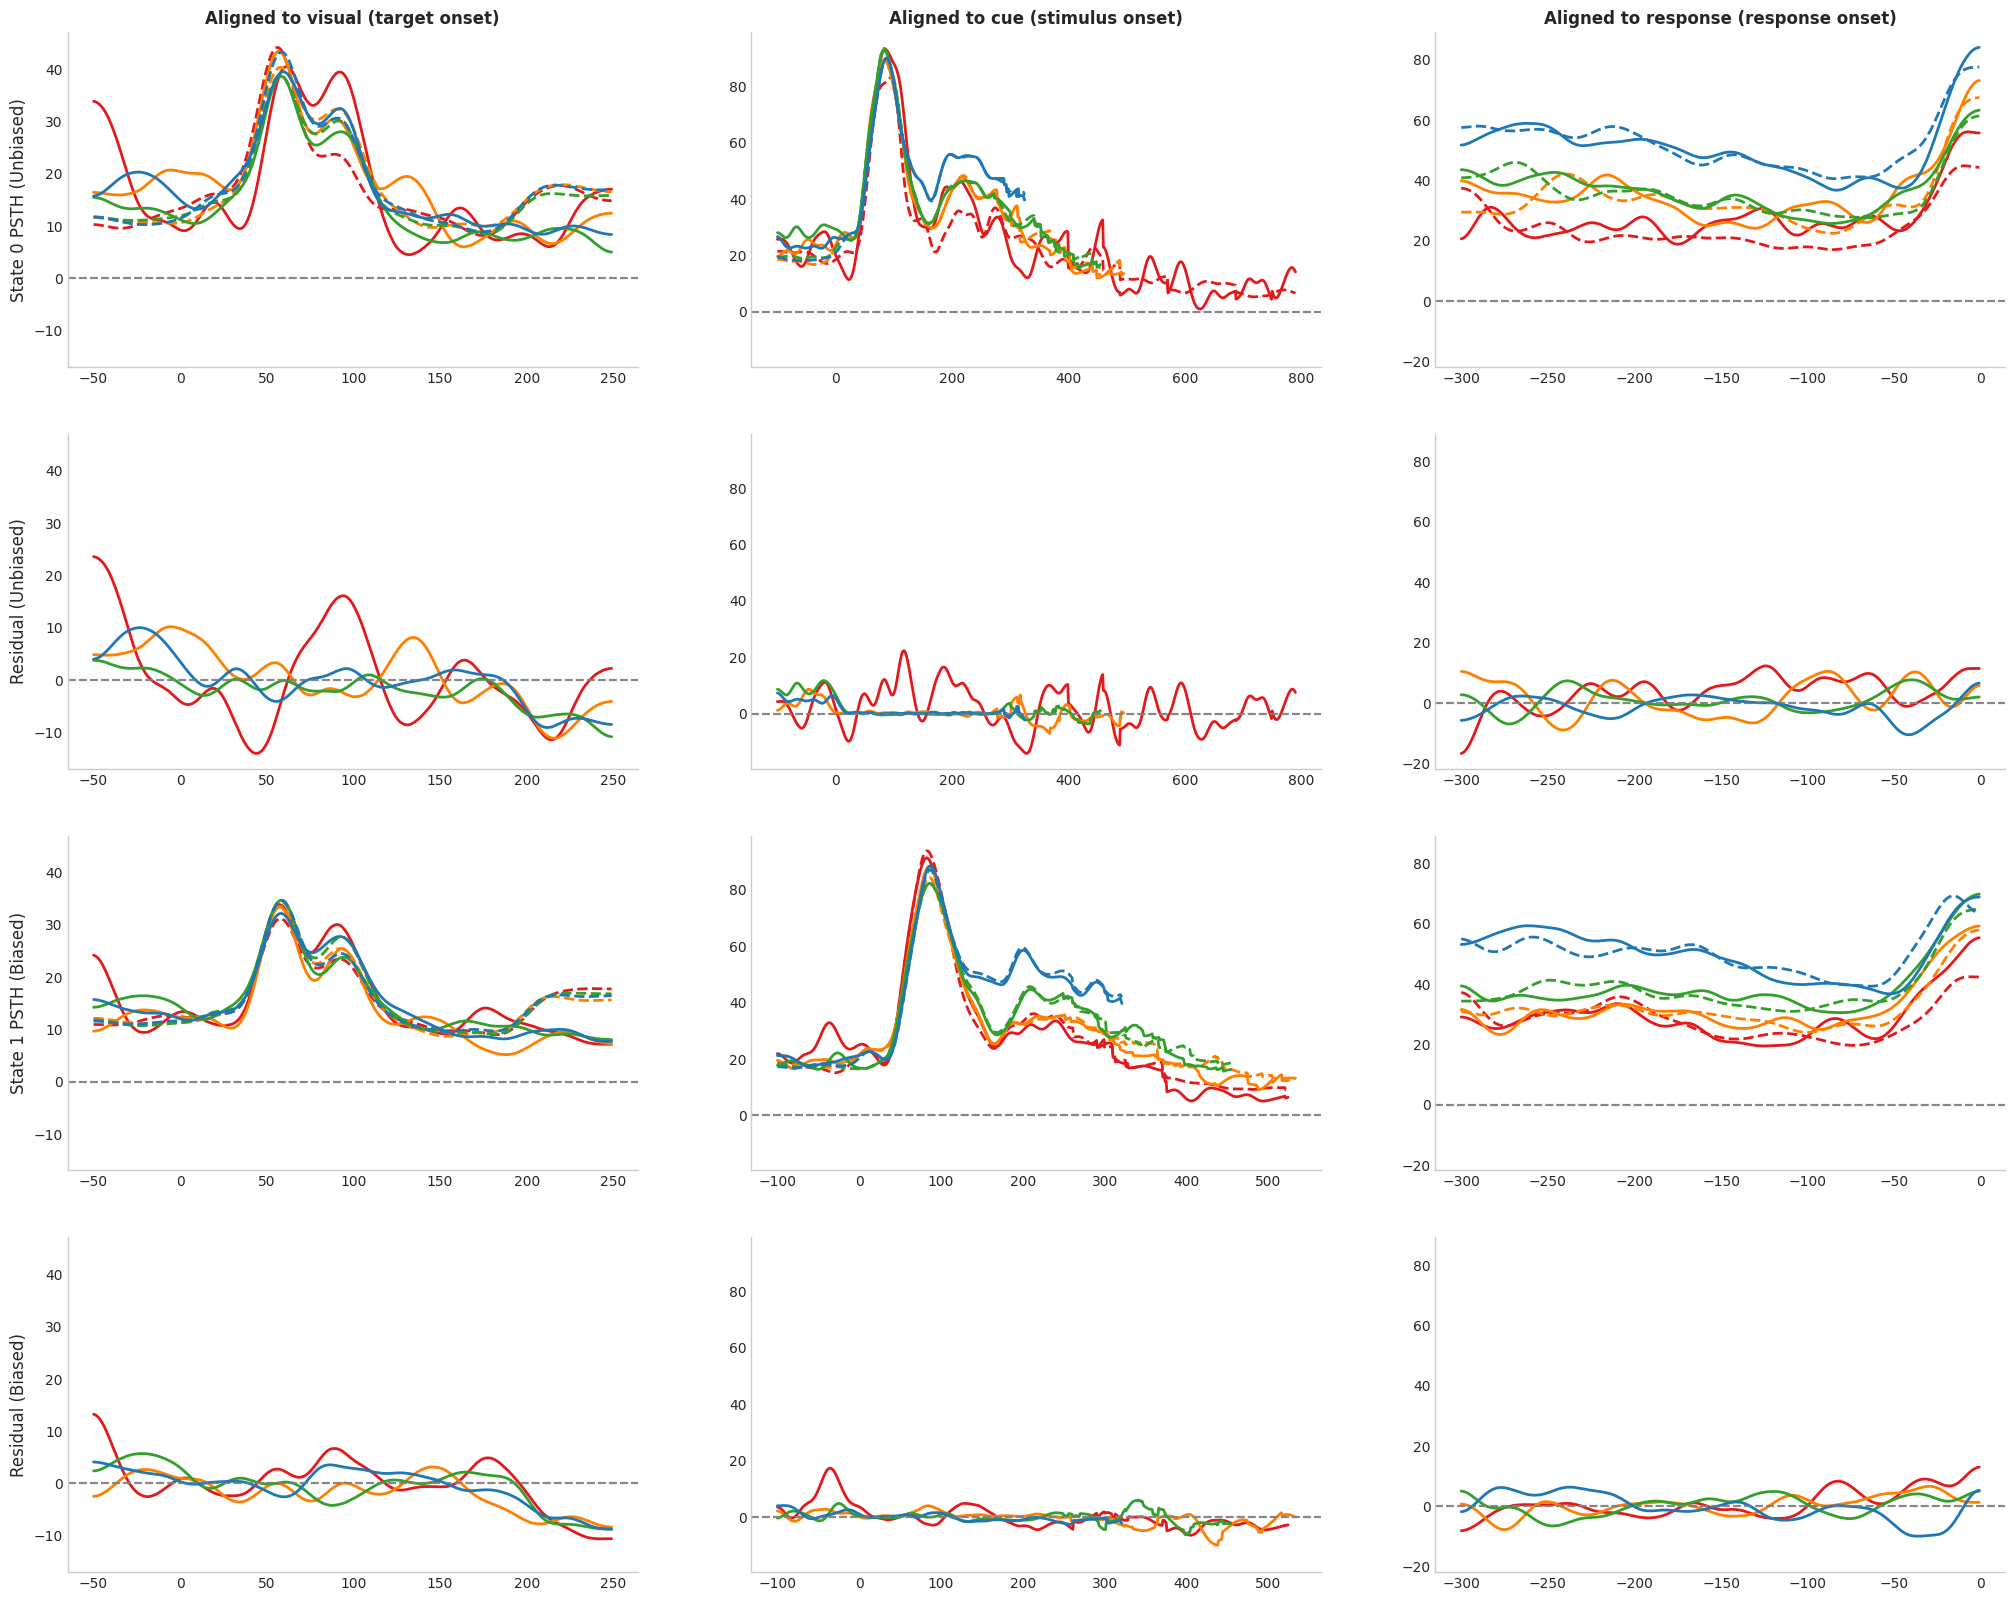

In [16]:
for neuron_id, result in fitting_result.items():
    trial_info = result['trial_info']
    plot_data_and_model_psth(trial_info, alignment_settings)

In [17]:
def match_ylim(ax_list):
    """Unify y-axis limits across multiple subplots based on their current data range."""
    ymins = [ax.get_ylim()[0] for ax in ax_list]
    ymaxs = [ax.get_ylim()[1] for ax in ax_list]
    common_ylim = (min(ymins), max(ymaxs))
    for ax in ax_list:
        ax.set_ylim(common_ylim)


def plot_kernels(neuron_id, result, coh_levels):
    fitted_weights = result['fitted_weights'][:-1]  # Exclude intercept
    kernels = reconstruct_kernels_from_weights(fitted_weights, poisson_glm_config)
    alpha = {0: 0.5, 1: 1.0}

    fig = plt.figure(figsize=(20, 15))
    gs = fig.add_gridspec(4, 3, height_ratios=[1, 1, 1, 1], width_ratios=[1, 1, 1.2])

    # ========================================================================
    # 1. TARGET ONSET KERNEL
    # ========================================================================
    target_axs = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0])]
    for ax, state_idx in zip(target_axs, range(poisson_glm_config.N_BIAS_STATES)):
        state_kernel = kernels[f'target_state_{state_idx}']
        ax.plot(state_kernel['time'], state_kernel['kernel'], linewidth=2, color='k',
                alpha=alpha[state_idx], label=f'State {state_idx}')
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_title(f'Target Component ({state_kernel["n_bases"]} bases, {state_kernel["duration_ms"]}ms)',
                      fontsize=11, fontweight='bold')
        ax.legend(fontsize=8, loc='upper right', ncol=2)
        ax.set_ylabel('Filter amplitude')
        ax.set_xlabel('Time (ms)')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, state_kernel["duration_ms"])
    match_ylim(target_axs)  # ✅ common y-limits

    # ========================================================================
    # 2. STIMULUS KERNELS
    # ========================================================================
    stimulus_axs = [fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1])]
    colors_coh = plt.cm.viridis(np.linspace(0, 1, poisson_glm_config.N_COHERENCE_LEVELS))
    for ax, state_idx in zip(stimulus_axs, range(poisson_glm_config.N_BIAS_STATES)):
        for coh_idx in range(poisson_glm_config.N_COHERENCE_LEVELS):
            kernel_key = f'stimulus_coh_{coh_idx}_state_{state_idx}'
            if kernel_key in kernels:
                coh_kernel = kernels[kernel_key]
                ax.plot(coh_kernel['time'], coh_kernel['kernel'],
                        color=colors_coh[coh_idx], linewidth=2, alpha=alpha[state_idx],
                        label=f'{coh_levels[coh_idx]*100}%')
        stim_avg = kernels['stimulus']
        ax.plot(stim_avg['time'], stim_avg['kernel'], 'k--', linewidth=3, alpha=0.9, label='Average')
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_title(f'Stimulus Component ({stim_avg["n_bases"]} bases × {poisson_glm_config.N_COHERENCE_LEVELS} coh, {stim_avg["duration_ms"]}ms)',
                      fontsize=11, fontweight='bold')
        ax.set_ylabel('Filter amplitude')
        ax.set_xlabel('Time (ms)')
        ax.legend(fontsize=8, loc='upper right', ncol=2)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, stim_avg["duration_ms"])
    match_ylim(stimulus_axs)

    # ========================================================================
    # 3. CHOICE/SACCADE KERNELS
    # ========================================================================
    choice_axs = [fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[1, 2])]
    choice_colors = ['dodgerblue', 'crimson']
    choice_labels = ['Choice 0', 'Choice 1']

    for ax, state_idx in zip(choice_axs, range(poisson_glm_config.N_BIAS_STATES)):
        for choice_idx in range(poisson_glm_config.N_CHOICE_OPTIONS):
            choice_kernel = kernels[f'choice_{choice_idx}_state_{state_idx}']
            ax.plot(choice_kernel['time'], choice_kernel['kernel'],
                    color=choice_colors[choice_idx], linewidth=3, alpha=alpha[state_idx],
                    label=choice_labels[choice_idx])
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(0, color='gray', linestyle=':', alpha=0.7, label='Saccade')
        ax.set_title(f'Choice Component ({choice_kernel["n_bases"]} bases × {poisson_glm_config.N_CHOICE_OPTIONS} choices, {choice_kernel["duration_ms"]}ms)',
                      fontsize=11, fontweight='bold')
        ax.set_ylabel('Filter amplitude')
        ax.set_xlabel('Time relative to saccade (ms)')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(choice_kernel["time"].min(), 0)
    match_ylim(choice_axs)

    # ========================================================================
    # 4. POST-SPIKE HISTORY KERNEL
    # ========================================================================
    ax5 = fig.add_subplot(gs[2,1])
    history_kernel = kernels['history']
    ax5.plot(history_kernel['time'], history_kernel['kernel'], 'purple', linewidth=3, alpha=0.8)
    ax5.axhline(0, color='gray', linestyle='--', alpha=0.5)
    # Mark uniform vs nonlinear regions
    ax5.axvline(history_kernel['uniform_duration_ms'], color='red', linestyle=':', alpha=0.7,
               label=f'Uniform→Nonlinear ({history_kernel["uniform_duration_ms"]}ms)')
    ax5.set_title(f'Post-Spike History ({history_kernel["n_uniform_bases"]}+{history_kernel["n_nonlinear_bases"]} bases, {history_kernel["total_duration_ms"]}ms)',
                  fontsize=11, fontweight='bold')
    ax5.set_ylabel('Filter amplitude')
    ax5.set_xlabel('Time after spike (ms)')
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)
    ax5.set_xlim(0, history_kernel["total_duration_ms"])



    plt.suptitle(f"Poisson GLM fitting for neuron {neuron_id}")
    plt.tight_layout()
    plt.subplots_adjust(top=0.94)
    plt.show()


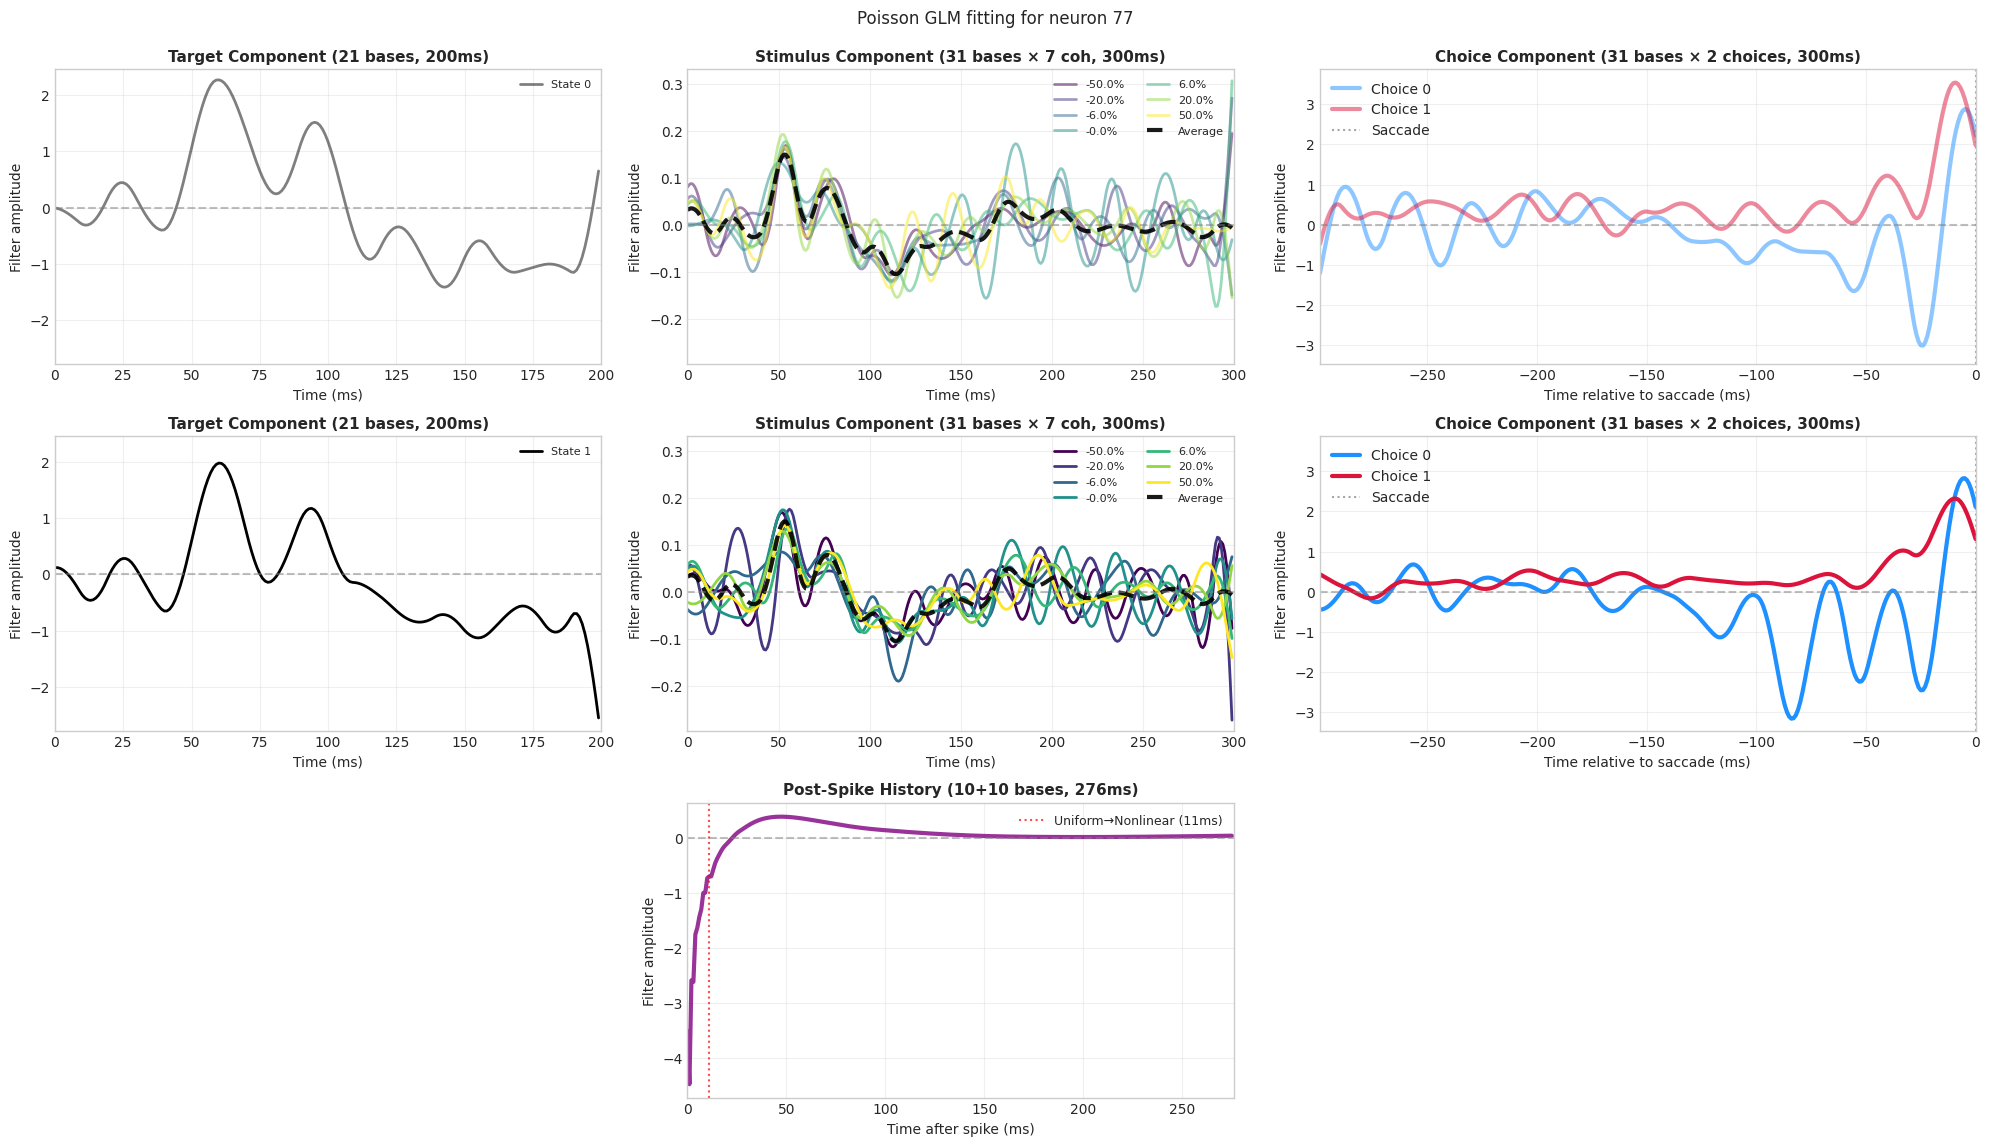

In [18]:
for neuron_id, result in fitting_result.items():
    plot_kernels(neuron_id, result, coh_levels)

### Model fit verification

In [19]:
def spike_train_convolved_array(trial_info):
    convolved_spike_density = []
    predicted_spike_rate = []
    sigma = 10  # 10ms smoothing

    for idx in range(len(trial_info)):
        trial_spike_train = trial_info.loc[idx, "spike_train"]
        trial_predicted_rate = trial_info.loc[idx, "predicted_spike_rate"]

        convolved_spike_density.append(gaussian_filter1d(trial_spike_train, sigma=sigma, truncate=3) * 1000) # gaussian smoothened
        predicted_spike_rate.append(gaussian_filter1d(trial_predicted_rate, sigma=sigma, truncate=3) * 1000)

    # convert to numpy array and make one long array
    convolved_spike_density = np.concatenate(convolved_spike_density)
    predicted_spike_rate = np.concatenate(predicted_spike_rate)
    return convolved_spike_density, predicted_spike_rate



MODEL FIT STATISTICS FOR NEURON 77
Data points used: 1,183,606

CORRELATION MEASURES:
  Pearson correlation:  r = 0.3266, p = 0.00e+00
  Spearman correlation: ρ = 0.2004, p = 0.00e+00

VARIANCE EXPLAINED:
  R² (coefficient of determination): -0.1284 (-12.8% variance explained)
  Explained variance (alternative):   -0.1284 (-12.8%)

ERROR METRICS:
  Mean Squared Error (MSE):  664.4149
  Root Mean Squared Error:   25.7762
  Mean Absolute Error:       19.8586

DATA SUMMARY:
  Actual spike rate - Mean: 22.58, Std: 24.27
  Predicted rate    - Mean: 22.57, Std: 19.69


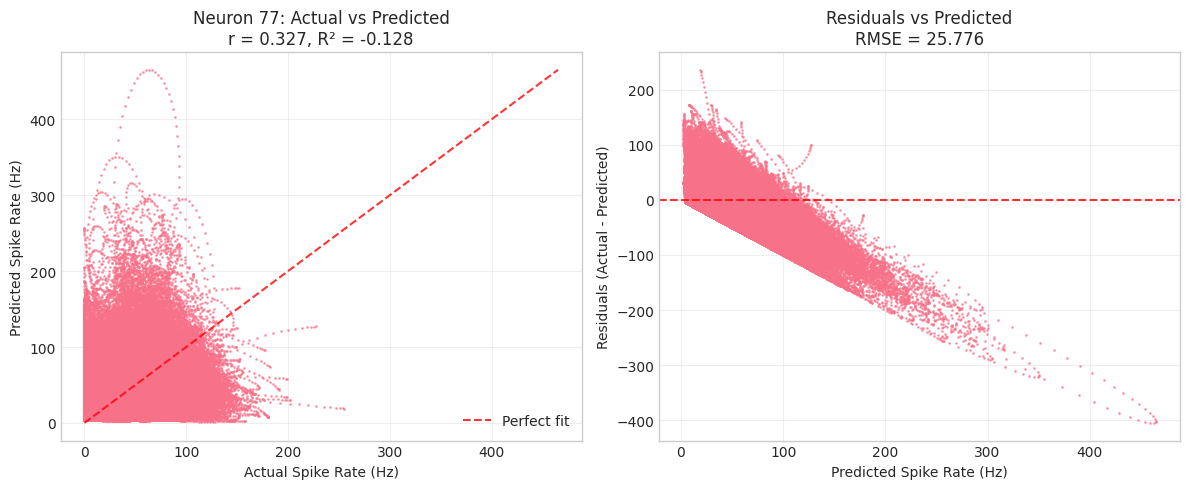

In [20]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score

for neuron_id, result in fitting_result.items():
    trial_info = result['trial_info']
    spike_train, predicted_spike_train = spike_train_convolved_array(trial_info)

    # Remove any NaN values for correlation calculations
    valid_indices = ~(np.isnan(spike_train) | np.isnan(predicted_spike_train))
    spike_train_clean = spike_train[valid_indices]
    predicted_spike_train_clean = predicted_spike_train[valid_indices]

    # 1. Pearson correlation (linear relationship)
    pearson_r, pearson_p = pearsonr(spike_train_clean, predicted_spike_train_clean)

    # 2. Spearman correlation (monotonic relationship)
    spearman_r, spearman_p = spearmanr(spike_train_clean, predicted_spike_train_clean)

    # 3. R-squared (coefficient of determination - variance explained)
    r2 = r2_score(spike_train_clean, predicted_spike_train_clean)

    # 4. Mean Squared Error
    mse = np.mean((spike_train_clean - predicted_spike_train_clean) ** 2)

    # 5. Root Mean Squared Error
    rmse = np.sqrt(mse)

    # 6. Mean Absolute Error
    mae = np.mean(np.abs(spike_train_clean - predicted_spike_train_clean))

    # 7. Explained variance (alternative calculation)
    explained_variance = 1 - (np.var(spike_train_clean - predicted_spike_train_clean) / np.var(spike_train_clean))

    print(f"\n{'='*60}")
    print(f"MODEL FIT STATISTICS FOR NEURON {neuron_id}")
    print(f"{'='*60}")
    print(f"Data points used: {len(spike_train_clean):,}")
    print(f"")
    print(f"CORRELATION MEASURES:")
    print(f"  Pearson correlation:  r = {pearson_r:.4f}, p = {pearson_p:.2e}")
    print(f"  Spearman correlation: ρ = {spearman_r:.4f}, p = {spearman_p:.2e}")
    print(f"")
    print(f"VARIANCE EXPLAINED:")
    print(f"  R² (coefficient of determination): {r2:.4f} ({r2*100:.1f}% variance explained)")
    print(f"  Explained variance (alternative):   {explained_variance:.4f} ({explained_variance*100:.1f}%)")
    print(f"")
    print(f"ERROR METRICS:")
    print(f"  Mean Squared Error (MSE):  {mse:.4f}")
    print(f"  Root Mean Squared Error:   {rmse:.4f}")
    print(f"  Mean Absolute Error:       {mae:.4f}")
    print(f"")
    print(f"DATA SUMMARY:")
    print(f"  Actual spike rate - Mean: {np.mean(spike_train_clean):.2f}, Std: {np.std(spike_train_clean):.2f}")
    print(f"  Predicted rate    - Mean: {np.mean(predicted_spike_train_clean):.2f}, Std: {np.std(predicted_spike_train_clean):.2f}")

    # Create scatter plot for visualization
    plt.figure(figsize=(12, 5))

    # Subplot 1: Scatter plot
    plt.subplot(1, 2, 1)
    plt.scatter(spike_train_clean, predicted_spike_train_clean, alpha=0.6, s=1)
    plt.plot([0, max(spike_train_clean.max(), predicted_spike_train_clean.max())],
             [0, max(spike_train_clean.max(), predicted_spike_train_clean.max())],
             'r--', alpha=0.8, label='Perfect fit')
    plt.xlabel('Actual Spike Rate (Hz)')
    plt.ylabel('Predicted Spike Rate (Hz)')
    plt.title(f'Neuron {neuron_id}: Actual vs Predicted\nr = {pearson_r:.3f}, R² = {r2:.3f}')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subplot 2: Residuals plot
    plt.subplot(1, 2, 2)
    residuals = spike_train_clean - predicted_spike_train_clean
    plt.scatter(predicted_spike_train_clean, residuals, alpha=0.6, s=1)
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.8)
    plt.xlabel('Predicted Spike Rate (Hz)')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.title(f'Residuals vs Predicted\nRMSE = {rmse:.3f}')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [21]:
# Add this to your analysis to diagnose the issue:

# 1. Check baseline performance
baseline_mse = np.mean((spike_train_clean - np.mean(spike_train_clean))**2)
model_mse = mse

print(f"Baseline MSE (mean predictor): {baseline_mse:.4f}")
print(f"Model MSE: {model_mse:.4f}")
print(f"Model is {model_mse/baseline_mse:.2f}x worse than baseline")

# 2. Check optimization convergence
print(f"Optimization success: {result.success}")
print(f"Final loss value: {result.fun:.2e}")
print(f"Number of iterations: {result.nit}")

# 3. Check weight magnitudes
weights = result['fitted_weights']
print(f"Weight statistics:")
print(f"  Mean: {np.mean(weights):.4f}")
print(f"  Std: {np.std(weights):.4f}")
print(f"  Max: {np.max(weights):.4f}")
print(f"  Min: {np.min(weights):.4f}")

# 4. Check prediction statistics
print(f"Prediction statistics:")
print(f"  Mean predicted rate: {np.mean(predicted_spike_train_clean):.2f} Hz")
print(f"  Mean actual rate: {np.mean(spike_train_clean):.2f} Hz")
print(f"  Predicted rate range: [{np.min(predicted_spike_train_clean):.2f}, {np.max(predicted_spike_train_clean):.2f}]")

Baseline MSE (mean predictor): 588.8306
Model MSE: 664.4149
Model is 1.13x worse than baseline
Optimization success: False
Final loss value: 1.16e+05
Number of iterations: 1000
Weight statistics:
  Mean: -28.1874
  Std: 639.4941
  Max: 1122.8272
  Min: -12745.4136
Prediction statistics:
  Mean predicted rate: 22.57 Hz
  Mean actual rate: 22.58 Hz
  Predicted rate range: [1.78, 465.18]


In [22]:
result

        message: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
        success: False
         status: 1
            fun: 116192.51777560811
              x: [-4.396e-04 -3.398e-02 ...  1.678e-01 -4.250e+00]
            nit: 1000
            jac: [ 3.234e+00  3.944e+00 ... -7.293e+00 -4.573e+00]
           nfev: 1050
           njev: 1050
       hess_inv: <705x705 LbfgsInvHessProduct with dtype=float64>
    predicted_y: [ 1.280e-02  1.280e-02 ...  9.641e-02  1.906e-01]
 fitted_weights: [-6.801e-03 -5.136e-01 ...  9.257e-02 -4.358e+00]
     timestamps:       fixation_onset  target_onset  stimulus_onset     go_onset  \
                 0           151085.0      187860.0             NaN     217436.0   
                 1           244642.0      280637.0             NaN     310603.0   
                 2           348188.0      380194.0             NaN     408180.0   
                 3           444956.0      482150.0             NaN     509746.0   
                 4           542922.0    

In [23]:
# Additional comprehensive diagnostics
# Add this after your existing diagnostic code:

# 5. Check design matrix conditioning
print(f"\nDESIGN MATRIX DIAGNOSTICS:")
X_check = X.toarray() if issparse(X) else X
print(f"  Design matrix shape: {X_check.shape}")
print(f"  Condition number: {np.linalg.cond(X_check.T @ X_check):.2e}")
print(f"  Matrix rank: {np.linalg.matrix_rank(X_check)} / {X_check.shape[1]}")
print(f"  Feature variance range: [{np.min(np.var(X_check, axis=0)):.2e}, {np.max(np.var(X_check, axis=0)):.2e}]")

# 6. Check for problematic features
feature_vars = np.var(X_check, axis=0)
zero_var_features = np.sum(feature_vars < 1e-10)
print(f"  Features with near-zero variance: {zero_var_features}")
print(f"  Max feature activation: {np.max(X_check):.2f}")

# 7. Check data sparsity
print(f"\nDATA QUALITY:")
print(f"  Spike train sparsity: {np.mean(spike_train_clean == 0)*100:.1f}% zeros")
print(f"  Mean spikes per bin: {np.mean(spike_train_clean):.4f}")
print(f"  Max spikes in any bin: {np.max(spike_train_clean)}")

# 8. Simple sklearn comparison
from sklearn.linear_model import PoissonRegressor
try:
    # Use simpler regularization
    simple_model = PoissonRegressor(alpha=0.1, max_iter=1000, fit_intercept=True)
    simple_model.fit(X_check[:, :-1], y)  # Exclude our intercept
    simple_pred = simple_model.predict(X_check[:, :-1])

    # Calculate R2 on smoothed data for fair comparison
    simple_pred_smooth = []
    for idx in range(len(trial_info)):
        start_idx = sum(trial_info.loc[:idx-1, 'n_bins']) if idx > 0 else 0
        end_idx = start_idx + trial_info.loc[idx, 'n_bins']
        trial_pred = simple_pred[start_idx:end_idx]
        simple_pred_smooth.append(gaussian_filter1d(trial_pred, sigma=10, truncate=3) * 1000)

    simple_pred_clean = np.concatenate(simple_pred_smooth)[valid_indices]
    simple_r2 = r2_score(spike_train_clean, simple_pred_clean)

    print(f"\nSKLEARN COMPARISON:")
    print(f"  Sklearn Poisson R²: {simple_r2:.4f}")
    print(f"  Our model R²: {r2:.4f}")
    print(f"  Sklearn weight range: [{np.min(simple_model.coef_):.2f}, {np.max(simple_model.coef_):.2f}]")

except Exception as e:
    print(f"\nSKLEARN COMPARISON FAILED: {e}")


DESIGN MATRIX DIAGNOSTICS:
  Design matrix shape: (1183606, 705)
  Condition number: 1.93e+24
  Matrix rank: 635 / 705
  Feature variance range: [0.00e+00, 1.74e+01]
  Features with near-zero variance: 57
  Max feature activation: 20.00

DATA QUALITY:
  Spike train sparsity: 27.8% zeros
  Mean spikes per bin: 22.5768
  Max spikes in any bin: 254.90472845038136

SKLEARN COMPARISON:
  Sklearn Poisson R²: 0.3318
  Our model R²: -0.1284
  Sklearn weight range: [-0.01, 0.03]


In [8]:
def fit_poisson_glm_improved(X, y):
    """Improved Poisson GLM fitting with better numerical stability"""
    if issparse(X):
        X = X.toarray()

    # Remove features with zero variance
    feature_vars = np.var(X, axis=0)
    valid_features = feature_vars > 1e-10
    X_filtered = X[:, valid_features]

    print(f"Removed {np.sum(~valid_features)} zero-variance features")
    print(f"Using {X_filtered.shape[1]} features")

    # Better standardization
    X_means = np.mean(X_filtered, axis=0)
    X_stds = np.std(X_filtered, axis=0)
    X_stds[X_stds < 1e-8] = 1.0

    X_scaled = (X_filtered - X_means) / X_stds
    X_scaled = np.clip(X_scaled, -5, 5)  # More conservative clipping

    # Add small ridge regularization to diagonal for numerical stability
    def loss_fun(w):
        eta = X_scaled @ w
        eta = np.clip(eta, -10, 10)  # Prevent extreme values
        mu = np.exp(eta)

        # Check for numerical issues
        if np.any(~np.isfinite(mu)):
            return 1e10

        # Poisson log-likelihood with L2 regularization
        log_likelihood = np.sum(y * eta - mu)
        regularization = 0.01 * np.sum(w**2)  # Reduced regularization
        return -log_likelihood + regularization

    def grad_fun(w):
        eta = X_scaled @ w
        eta = np.clip(eta, -10, 10)
        mu = np.exp(eta)

        if np.any(~np.isfinite(mu)):
            return np.full_like(w, 1e10)

        gradient = X_scaled.T @ (mu - y) + 0.02 * w
        return gradient

    # Better initialization
    n_features = X_scaled.shape[1]
    w_init = np.zeros(n_features)

    # Initialize intercept to log of mean rate
    mean_rate = np.mean(y)
    if mean_rate > 0:
        w_init[-1] = np.log(mean_rate)

    print(f"Initial loss: {loss_fun(w_init):.2e}")

    # Try multiple optimization strategies
    results = []
    methods = ['L-BFGS-B', 'TNC']

    for method in methods:
        print(f"Trying {method}...")
        try:
            result = minimize(
                fun=loss_fun,
                x0=w_init,
                method=method,
                jac=grad_fun,
                options={
                    'maxiter': 2000,
                    'gtol': 1e-5,
                    'ftol': 1e-8,
                    'maxfun': 10000
                }
            )
            results.append((result, method))
            print(f"{method}: success={result.success}, fun={result.fun:.2e}, nit={result.nit}")

            if result.success:
                break

        except Exception as e:
            print(f"{method} failed: {e}")
            continue

    if not results:
        print("All optimization methods failed!")
        return None

    # Use best result
    best_result, best_method = min(results, key=lambda x: x[0].fun)
    print(f"Best result from {best_method}")

    # Transform weights back
    weights_scaled = best_result.x
    fitted_weights_filtered = weights_scaled / X_stds

    # Reconstruct full weight vector
    fitted_weights = np.zeros(X.shape[1])
    fitted_weights[valid_features] = fitted_weights_filtered

    # Adjust intercept
    if valid_features[-1]:  # If intercept was kept
        fitted_weights[-1] = weights_scaled[-1] - np.dot(weights_scaled[:-1], X_means[:-1] / X_stds[:-1])

    # Generate predictions
    eta = X_scaled @ weights_scaled
    predicted = np.exp(np.clip(eta, -10, 10))

    # Store results
    best_result['fitted_weights'] = fitted_weights
    best_result['predicted_y'] = predicted
    best_result['valid_features'] = valid_features
    best_result['optimization_method'] = best_method

    return best_result

In [9]:
def fit_poisson_glm_sklearn(X, y):
    """Alternative fitting using sklearn for comparison"""
    from sklearn.linear_model import PoissonRegressor
    from sklearn.preprocessing import StandardScaler

    if issparse(X):
        X = X.toarray()

    # Remove intercept column and zero-variance features
    X_no_intercept = X[:, :-1]
    feature_vars = np.var(X_no_intercept, axis=0)
    valid_features = feature_vars > 1e-10
    X_filtered = X_no_intercept[:, valid_features]

    print(f"Sklearn: Using {X_filtered.shape[1]} features (removed {np.sum(~valid_features)} zero-variance)")

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_filtered)

    # Fit model with cross-validation for alpha
    from sklearn.model_selection import cross_val_score
    alphas = [0.001, 0.01, 0.1, 1.0]
    best_alpha = 0.01
    best_score = -np.inf

    for alpha in alphas:
        model = PoissonRegressor(alpha=alpha, max_iter=2000, fit_intercept=True)
        try:
            scores = cross_val_score(model, X_scaled, y, cv=3, scoring='neg_mean_squared_error')
            mean_score = np.mean(scores)
            if mean_score > best_score:
                best_score = mean_score
                best_alpha = alpha
        except:
            continue

    print(f"Best alpha: {best_alpha}")

    # Fit final model
    final_model = PoissonRegressor(alpha=best_alpha, max_iter=2000, fit_intercept=True)
    final_model.fit(X_scaled, y)

    # Generate predictions
    predicted = final_model.predict(X_scaled)

    # Reconstruct full weight vector
    full_weights = np.zeros(X.shape[1])
    full_weights[:-1][valid_features] = final_model.coef_
    full_weights[-1] = final_model.intercept_

    # Create result object
    result = {
        'fitted_weights': full_weights,
        'predicted_y': predicted,
        'valid_features': np.append(valid_features, True),  # Include intercept
        'sklearn_model': final_model,
        'scaler': scaler,
        'success': True,
        'method': 'sklearn_poisson'
    }

    return result

In [ ]:
# Test improved fitting with better memory management and error handling
fitting_result_improved = {}
fitting_result_sklearn = {}

import gc  # For garbage collection

for neuron_id in [77]:
    print(f"\n{'='*60}")
    print(f"FITTING NEURON {neuron_id}")
    print(f"{'='*60}")

    try:
        # Clear memory before starting
        gc.collect()

        session_data, neuron_spike_times, timestamps, coh_levels = extract_neuron_data(neuron_id)
        trials = create_neuroglm_trials(session_data, timestamps, neuron_spike_times, poisson_glm_config.BIN_SIZE_MS)
        X, y = build_design_matrix(trials, coh_levels)

        print(f"Data shape: X={X.shape}, y={y.shape}")
        print(f"Spike rate: mean={np.mean(y):.3f}, max={np.max(y)}")

        # Convert sparse matrix to dense early and check memory
        if issparse(X):
            print("Converting sparse matrix to dense...")
            X = X.toarray()
            gc.collect()  # Clean up sparse matrix memory

        # Check for memory issues
        memory_usage_mb = X.nbytes / (1024**2)
        print(f"Design matrix memory usage: {memory_usage_mb:.1f} MB")

        if memory_usage_mb > 1000:  # If > 1GB
            print("WARNING: Large design matrix may cause memory issues")

        # Method 1: Improved custom optimization
        print(f"\n--- IMPROVED CUSTOM OPTIMIZATION ---")
        try:
            result_improved = fit_poisson_glm_improved(X, y)

            if result_improved is not None:
                result_improved['timestamps'] = timestamps
                result_improved['coh_levels'] = coh_levels
                result_improved['trial_info'] = pd.DataFrame(trials)

                # Process trial predictions more efficiently
                predicted_y = []
                onset = 0
                for i, n_bins in enumerate(result_improved['trial_info']["n_bins"]):
                    trial_pred = result_improved["predicted_y"][onset:onset + n_bins].copy()
                    predicted_y.append(trial_pred)
                    onset += n_bins

                result_improved["trial_info"]['predicted_spike_rate'] = predicted_y
                fitting_result_improved[neuron_id] = result_improved
                print("Improved fitting completed successfully")
            else:
                print("Improved fitting failed")

        except Exception as e:
            print(f"Improved fitting failed with error: {e}")
            result_improved = None

        # Method 2: Sklearn comparison
        print(f"\n--- SKLEARN COMPARISON ---")
        try:
            result_sklearn = fit_poisson_glm_sklearn(X, y)

            if result_sklearn is not None:
                result_sklearn['timestamps'] = timestamps
                result_sklearn['coh_levels'] = coh_levels
                result_sklearn['trial_info'] = pd.DataFrame(trials)

                # Process trial predictions more efficiently
                predicted_y = []
                onset = 0
                for i, n_bins in enumerate(result_sklearn['trial_info']["n_bins"]):
                    trial_pred = result_sklearn["predicted_y"][onset:onset + n_bins].copy()
                    predicted_y.append(trial_pred)
                    onset += n_bins

                result_sklearn["trial_info"]['predicted_spike_rate'] = predicted_y
                fitting_result_sklearn[neuron_id] = result_sklearn
                print("Sklearn fitting completed successfully")
            else:
                print("Sklearn fitting failed")

        except Exception as e:
            print(f"Sklearn fitting failed with error: {e}")
            result_sklearn = None

        # Clean up large variables
        del X, y
        gc.collect()

    except Exception as e:
        print(f"Fatal error processing neuron {neuron_id}: {e}")
        import traceback
        traceback.print_exc()
        continue

    break  # Only process one neuron for testing

print("\nFitting completed!")


FITTING NEURON 77
Analyzing neuron 77 from session 210601_GP_JP
Found 771 valid trials
Neuron has 156873 spikes
State distribution: {1.0: 423, 0.0: 348}
Data shape: X=(1183606, 705), y=(1183606,)
Spike rate: mean=0.023, max=2.0
Converting sparse matrix to dense...
Design matrix memory usage: 6366.3 MB

--- IMPROVED CUSTOM OPTIMIZATION ---
Removed 57 zero-variance features
Using 648 features
Initial loss: 1.81e+07
Trying L-BFGS-B...
L-BFGS-B: success=False, fun=5.91e+05, nit=2000
Trying TNC...


KeyboardInterrupt: 

: 